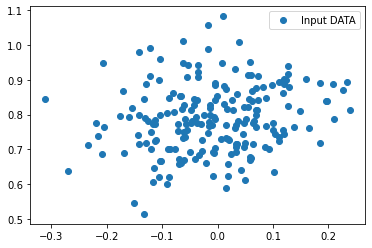

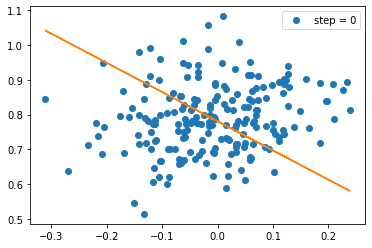

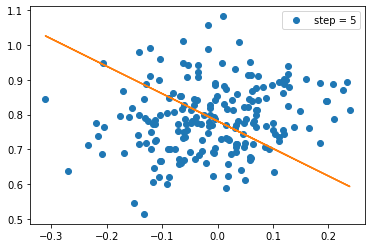

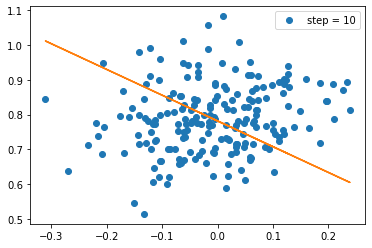

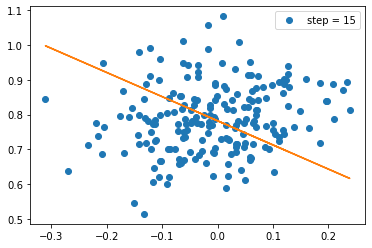

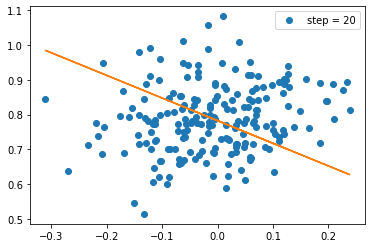

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.compat.v1.disable_eager_execution()
number_of_points = 200
x_point = []
y_point = []

a = 0.22
b = 0.78

for i in range(number_of_points):
    x = np.random.normal(0.0,0.1)
    y = a*x + b + np.random.normal(0.0,0.1)
    x_point.append([x])
    y_point.append([y])

plt.plot(x_point,y_point,'o',label='Input DATA')
plt.legend()
plt.show()

A = tf.Variable(tf.random.uniform([1],-1.0,1.0))
B = tf.Variable(tf.zeros([1]))
y = A * x_point + B

cost_function = tf.math.reduce_mean(tf.square(y-y_point))
optimizer = tf.compat.v1.train.GradientDescentOptimizer(0.5)
train = optimizer.minimize(cost_function)
model = tf.compat.v1.global_variables_initializer()

with tf.compat.v1.Session() as sess:
    sess.run(model)
    for step in range(0,21):
        sess.run(train)
        if step%5 == 0:
            plt.plot(x_point,y_point,'o',label='step = {}'.format(step))
            plt.plot(x_point,sess.run(A)*x_point + sess.run(B))
            plt.legend()
            plt.show()